# Paper Analysis: Similarity-Aware Techniques for Deduplication in Large-Scale Remote Sensing Data

## Results & Benchmarks

### Reproduction of Tables to Plots

**Original Table I: Feature Extraction Speed Comparison (100 Images, 768-Dimension)**

| Method | Total Time (s) | Time per Image (ms) | Relative to Custom Model |
| --- | ---: | ---: | ---: |
| Lightweight Transformer | 0.458 | 4.58 | 1.00x |
| Conventional ViT-B/16 | 0.933 | 9.33 | 2.04x |
| LBP | 5.892 | 58.92 | 12.87x |

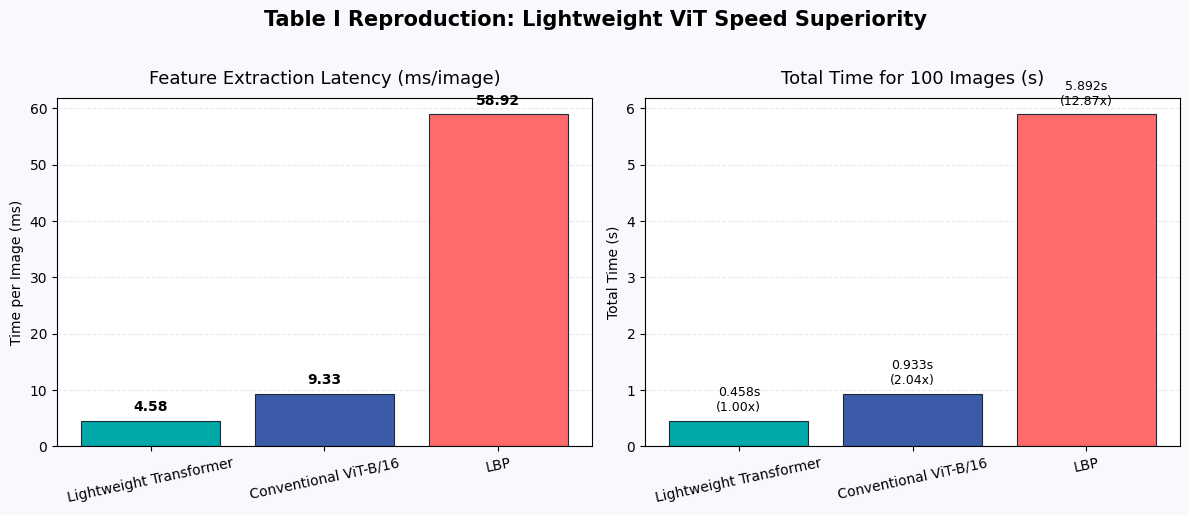

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# TABLE I values from the paper
speed_df = pd.DataFrame({
    "Method": ["Lightweight Transformer", "Conventional ViT-B/16", "LBP"],
    "Total Time (s)": [0.458, 0.933, 5.892],
    "Time per Image (ms)": [4.58, 9.33, 58.92],
    "Relative to Custom": [1.00, 2.04, 12.87]
})

palette = ["#00A8A8", "#3B5BA9", "#FF6B6B"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor("#F7F9FC")

# Left: latency per image
ax0 = axes[0]
bars0 = ax0.bar(speed_df["Method"], speed_df["Time per Image (ms)"], color=palette, edgecolor="#1f2937", linewidth=0.8)
ax0.set_title("Feature Extraction Latency (ms/image)", fontsize=13, pad=10)
ax0.set_ylabel("Time per Image (ms)")
ax0.grid(axis="y", linestyle="--", alpha=0.25)
ax0.set_axisbelow(True)
ax0.tick_params(axis="x", rotation=12)
for bar, val in zip(bars0, speed_df["Time per Image (ms)"]):
    ax0.annotate(f"{val:.2f}",
                 xy=(bar.get_x() + bar.get_width() / 2, val),
                 xytext=(0, 5), textcoords="offset points",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")

# Right: total processing time + relative factors
ax1 = axes[1]
bars1 = ax1.bar(speed_df["Method"], speed_df["Total Time (s)"], color=palette, edgecolor="#1f2937", linewidth=0.8)
ax1.set_title("Total Time for 100 Images (s)", fontsize=13, pad=10)
ax1.set_ylabel("Total Time (s)")
ax1.grid(axis="y", linestyle="--", alpha=0.25)
ax1.set_axisbelow(True)
ax1.tick_params(axis="x", rotation=12)
for bar, total, rel in zip(bars1, speed_df["Total Time (s)"], speed_df["Relative to Custom"]):
    ax1.annotate(f"{total:.3f}s\n({rel:.2f}x)",
                 xy=(bar.get_x() + bar.get_width() / 2, total),
                 xytext=(0, 5), textcoords="offset points",
                 ha="center", va="bottom", fontsize=9)

fig.suptitle("Table I Reproduction: Lightweight ViT Speed Superiority", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
plt.close()

**Original Table II: Classification Performance on WHU-RS19**

| Methods | Accuracy (%) |
| --- | ---: |
| B-CNN | 82.83 |
| ResNeXt-50 | 83.27 |
| TAE-Net | 88.04 |
| Lightweight Transformer | 98.36 |

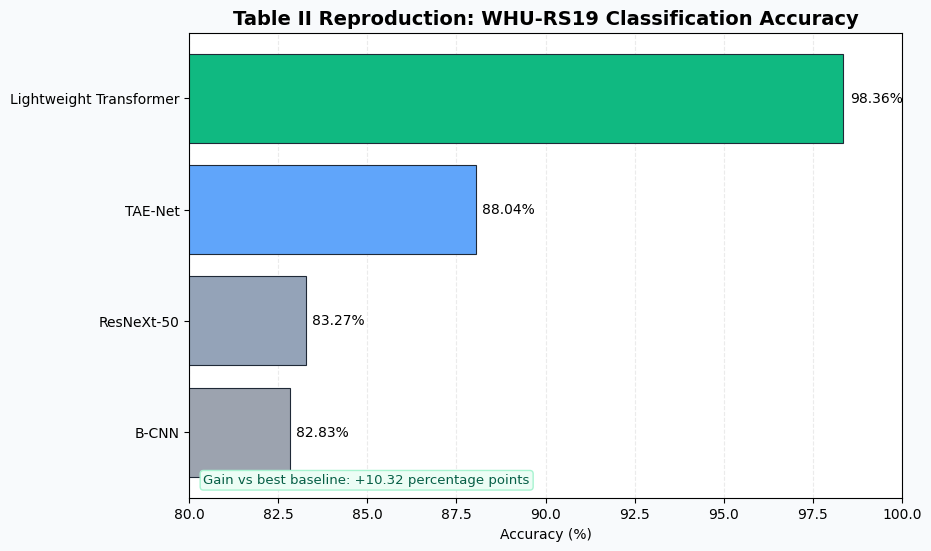

In [2]:
# TABLE II: WHU-RS19 accuracy comparison
import matplotlib.pyplot as plt
import numpy as np

whu_methods = ["B-CNN", "ResNeXt-50", "TAE-Net", "Lightweight Transformer"]
whu_acc = [82.83, 83.27, 88.04, 98.36]
colors = ["#9CA3AF", "#94A3B8", "#60A5FA", "#10B981"]

fig, ax = plt.subplots(figsize=(9.2, 5.4), constrained_layout=True)
fig.patch.set_facecolor("#F8FAFC")

bars = ax.barh(whu_methods, whu_acc, color=colors, edgecolor="#1f2937", linewidth=0.8)
ax.set_xlim(80, 100)
ax.set_xlabel("Accuracy (%)")
ax.set_title("Table II Reproduction: WHU-RS19 Classification Accuracy", fontsize=14, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

for bar, val in zip(bars, whu_acc):
    ax.text(val + 0.18, bar.get_y() + bar.get_height() / 2, f"{val:.2f}%", va="center", fontsize=10)

improvement = whu_acc[-1] - max(whu_acc[:-1])
ax.text(
    0.02, 0.03,
    f"Gain vs best baseline: +{improvement:.2f} percentage points",
    transform=ax.transAxes,
    fontsize=9.5,
    color="#065F46",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="#ECFDF5", edgecolor="#A7F3D0")
)

plt.show()
plt.close()

**Original Table III: Macro-Average Classification Performance on UCMerced**

| Method | Precision (%) | Recall (%) | F1 (%) |
| --- | ---: | ---: | ---: |
| ResNet-50 | 91.99 | 91.74 | 91.65 |
| DeiT-B | 89.14 | 88.73 | 88.70 |
| Swin-B | 91.85 | 91.74 | 91.62 |
| Lightweight Transformer | 97.29 | 97.26 | 97.27 |

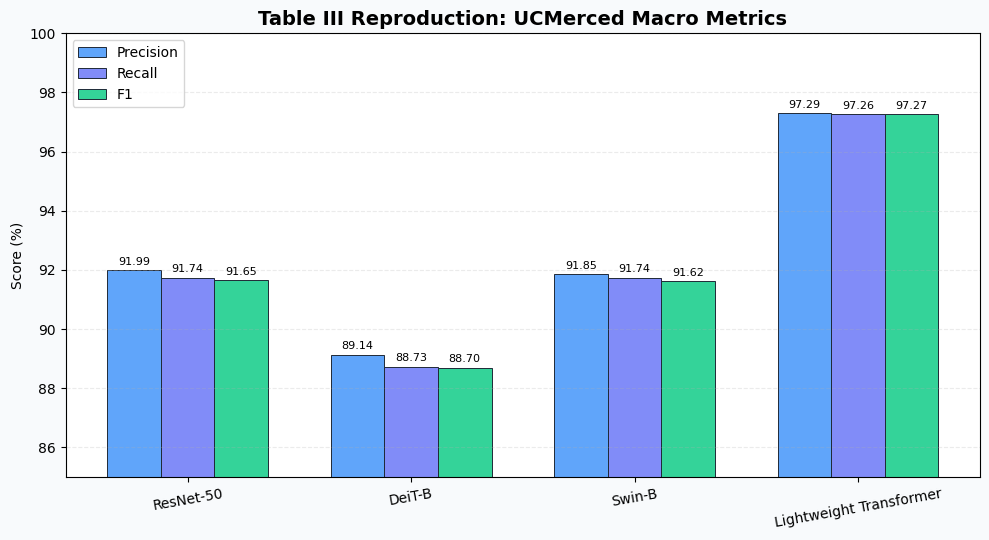

In [4]:
# TABLE III: UCMerced macro-average metrics
import matplotlib.pyplot as plt
import numpy as np

models = ["ResNet-50", "DeiT-B", "Swin-B", "Lightweight Transformer"]
precision = [91.99, 89.14, 91.85, 97.29]
recall = [91.74, 88.73, 91.74, 97.26]
f1 = [91.65, 88.70, 91.62, 97.27]

x = np.arange(len(models))
w = 0.24

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("#F8FAFC")

b1 = ax.bar(x - w, precision, width=w, color="#60A5FA", label="Precision", edgecolor="#1f2937", linewidth=0.7)
b2 = ax.bar(x, recall, width=w, color="#818CF8", label="Recall", edgecolor="#1f2937", linewidth=0.7)
b3 = ax.bar(x + w, f1, width=w, color="#34D399", label="F1", edgecolor="#1f2937", linewidth=0.7)

ax.set_title("Table III Reproduction: UCMerced Macro Metrics", fontsize=14, fontweight="bold")
ax.set_ylabel("Score (%)")
ax.set_ylim(85, 100)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=10)
ax.legend(frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.25)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.12, f"{h:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()
plt.close()

**Original Table IV: Deduplication Benchmark Table**

| Metric | Lightweight Transformer | Global CNN-Based Deduplication | Hash-based Deduplication |
| --- | ---: | ---: | ---: |
| Processing Time (s) | 6.3880 | 122.1222 | 50.2196 |
| Number of Comparisons | 1,516,200 | 28,876,200 | 28,876,200 |
| Number of Duplicates Found | 2,577 | 2,578 | 1,064 |

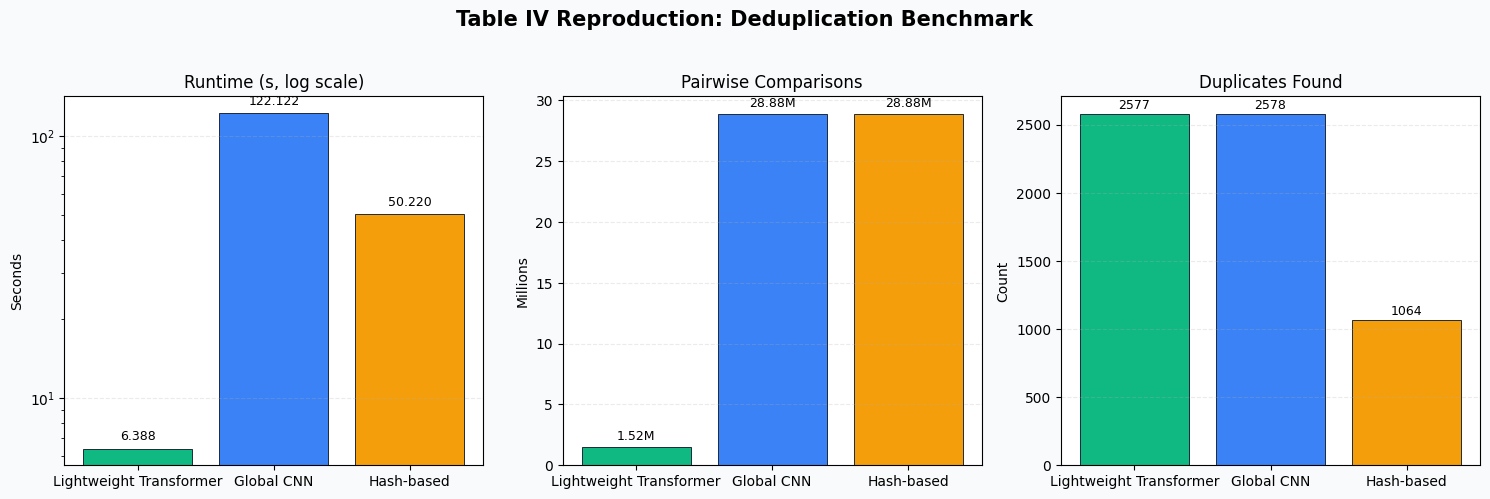

In [5]:
# Detailed deduplication comparison based on paper table
import matplotlib.pyplot as plt
import numpy as np

methods = ["Lightweight Transformer", "Global CNN", "Hash-based"]
runtime_s = [6.3880, 122.1222, 50.2196]
comparisons = [1_516_200, 28_876_200, 28_876_200]
duplicates_found = [2577, 2578, 1064]

colors = ["#10B981", "#3B82F6", "#F59E0B"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
fig.patch.set_facecolor("#F8FAFC")

# Runtime
ax0 = axes[0]
b0 = ax0.bar(methods, runtime_s, color=colors, edgecolor="#1f2937", linewidth=0.7)
ax0.set_yscale("log")
ax0.set_title("Runtime (s, log scale)")
ax0.set_ylabel("Seconds")
ax0.grid(axis="y", linestyle="--", alpha=0.25)
for bar, v in zip(b0, runtime_s):
    ax0.text(bar.get_x()+bar.get_width()/2, v*1.05, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

# Number of pairwise comparisons
ax1 = axes[1]
comp_m = [c / 1_000_000 for c in comparisons]
b1 = ax1.bar(methods, comp_m, color=colors, edgecolor="#1f2937", linewidth=0.7)
ax1.set_title("Pairwise Comparisons")
ax1.set_ylabel("Millions")
ax1.grid(axis="y", linestyle="--", alpha=0.25)
for bar, v in zip(b1, comp_m):
    ax1.text(bar.get_x()+bar.get_width()/2, v + 0.35, f"{v:.2f}M", ha="center", va="bottom", fontsize=9)

# Duplicates found
ax2 = axes[2]
b2 = ax2.bar(methods, duplicates_found, color=colors, edgecolor="#1f2937", linewidth=0.7)
ax2.set_title("Duplicates Found")
ax2.set_ylabel("Count")
ax2.grid(axis="y", linestyle="--", alpha=0.25)
for bar, v in zip(b2, duplicates_found):
    ax2.text(bar.get_x()+bar.get_width()/2, v + 20, f"{v}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Table IV Reproduction: Deduplication Benchmark", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()
plt.close()

### Creation of New Plots & Analysis

**I. Case Study: Archive Size and Downlink Savings (1000 images, 0.5 MB each)**

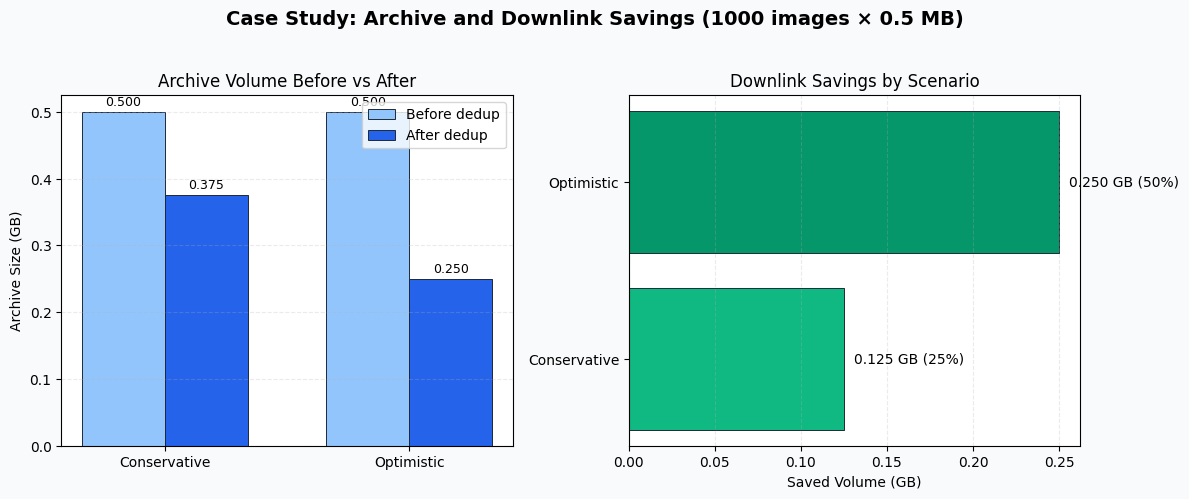

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Case-study assumptions
scenarios = ["Conservative", "Optimistic"]
reduction_pct = np.array([25, 50])
before_gb = np.array([0.50, 0.50])
after_gb = before_gb * (1 - reduction_pct / 100)
saved_gb = before_gb - after_gb

x = np.arange(len(scenarios))
width = 0.34

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
fig.patch.set_facecolor("#F8FAFC")

# Left panel: before vs after volumes
ax0 = axes[0]
b1 = ax0.bar(x - width / 2, before_gb, width, label="Before dedup", color="#93C5FD", edgecolor="#1f2937", linewidth=0.7)
b2 = ax0.bar(x + width / 2, after_gb, width, label="After dedup", color="#2563EB", edgecolor="#1f2937", linewidth=0.7)

for i in range(len(scenarios)):
    ax0.text(x[i] - width / 2, before_gb[i] + 0.01, f"{before_gb[i]:.3f}", ha="center", fontsize=9)
    ax0.text(x[i] + width / 2, after_gb[i] + 0.01, f"{after_gb[i]:.3f}", ha="center", fontsize=9)

ax0.set_xticks(x)
ax0.set_xticklabels(scenarios)
ax0.set_ylabel("Archive Size (GB)")
ax0.set_title("Archive Volume Before vs After")
ax0.grid(axis="y", linestyle="--", alpha=0.25)
ax0.legend(frameon=True)

# Right panel: savings emphasis
ax1 = axes[1]
b3 = ax1.barh(scenarios, saved_gb, color=["#10B981", "#059669"], edgecolor="#1f2937", linewidth=0.7)
for bar, val, pct in zip(b3, saved_gb, reduction_pct):
    ax1.text(val + 0.006, bar.get_y() + bar.get_height() / 2, f"{val:.3f} GB ({pct}%)", va="center", fontsize=10)

ax1.set_xlabel("Saved Volume (GB)")
ax1.set_title("Downlink Savings by Scenario")
ax1.grid(axis="x", linestyle="--", alpha=0.25)

fig.suptitle("Case Study: Archive and Downlink Savings (1000 images × 0.5 MB)", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()
plt.close()

**II. Derived Cross-Benchmark Improvement Dashboard**

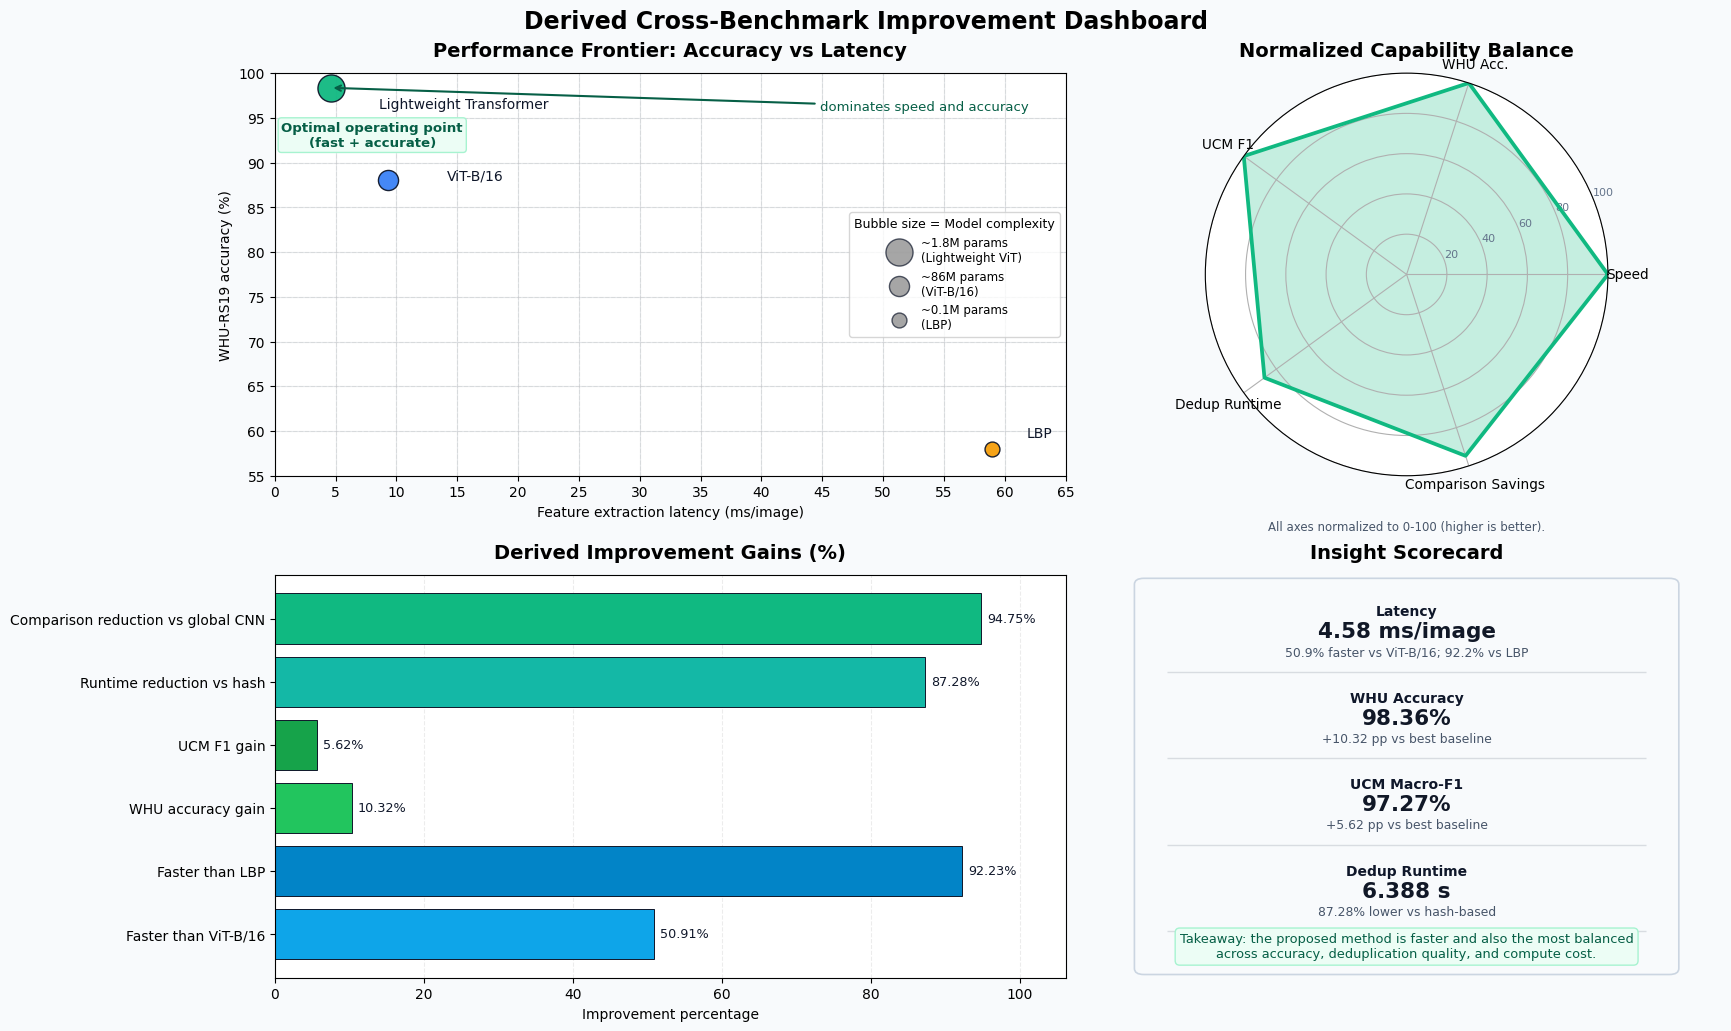

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import numpy as np
import textwrap

# Reported benchmark values (from the paper tables)
latency_ms = {
    "Lightweight Transformer": 4.58,
    "ViT-B/16": 9.33,
    "LBP": 58.92,
}

whu_acc = {
    "Lightweight Transformer": 98.36,
    "TAE-Net": 88.04,
    "ResNeXt-50": 83.27,
    "B-CNN": 82.83,
}

ucm_f1 = {
    "Lightweight Transformer": 97.27,
    "ResNet-50": 91.65,
    "Swin-B": 91.62,
    "DeiT-B": 88.70,
}

dedup_runtime_s = {
    "Lightweight Transformer": 6.3880,
    "Hash-based": 50.2196,
    "Global CNN": 122.1222,
}

dedup_comparisons_m = {
    "Lightweight Transformer": 1.5162,
    "Hash-based": 28.8762,
    "Global CNN": 28.8762,
}

# Derived deltas for concise insight callouts
speed_gain_vs_vit = (1 - latency_ms["Lightweight Transformer"] / latency_ms["ViT-B/16"]) * 100
speed_gain_vs_lbp = (1 - latency_ms["Lightweight Transformer"] / latency_ms["LBP"]) * 100
acc_gain_vs_best_baseline = whu_acc["Lightweight Transformer"] - max(
    v for k, v in whu_acc.items() if k != "Lightweight Transformer"
 )
f1_gain_vs_best_baseline = ucm_f1["Lightweight Transformer"] - max(
    v for k, v in ucm_f1.items() if k != "Lightweight Transformer"
 )
runtime_reduction_vs_hash = (1 - dedup_runtime_s["Lightweight Transformer"] / dedup_runtime_s["Hash-based"]) * 100
comparison_reduction_vs_global = (1 - dedup_comparisons_m["Lightweight Transformer"] / dedup_comparisons_m["Global CNN"]) * 100

fig = plt.figure(figsize=(17.2, 10.2), layout="constrained")
fig.patch.set_facecolor("#F8FAFC")
gs = fig.add_gridspec(2, 2, width_ratios=[1.28, 1.02], height_ratios=[1.0, 1.0])

# Panel 1 (top-left): Frontier (Accuracy vs Latency)
ax0 = fig.add_subplot(gs[0, 0])
frontier_points = [
    ("Lightweight Transformer", latency_ms["Lightweight Transformer"], whu_acc["Lightweight Transformer"], 380, "#10B981"),
    ("ViT-B/16", latency_ms["ViT-B/16"], whu_acc["TAE-Net"], 210, "#3B82F6"),
    ("LBP", latency_ms["LBP"], 58.0, 115, "#F59E0B"),
]

label_offsets = {
    "Lightweight Transformer": (35, -15),
    "ViT-B/16": (42, 0),
    "LBP": (25, 8),
}

for name, x, y, size, color in frontier_points:
    ax0.scatter(x, y, s=size, color=color, edgecolor="#0F172A", linewidth=1.0, alpha=0.95, zorder=3)
    ax0.annotate(name, (x, y), xytext=label_offsets[name], textcoords="offset points", fontsize=10, color="#0F172A")

# Linear x-axis with regular step ticks
x_min, x_max = 0, 65
y_min, y_max = 55, 100
ax0.set_xlim(x_min, x_max)
ax0.set_xticks(np.arange(x_min, x_max + 1, 5))
ax0.set_ylim(y_min, y_max)

# Draw checkered grid borders
x_edges = np.arange(x_min, x_max + 5, 5)
y_edges = np.arange(y_min, y_max + 5, 5)
for x in x_edges:
    ax0.axvline(x, color="#D8DCE1", linewidth=0.8, alpha=0.7, zorder=1.5)
for y in y_edges:
    ax0.axhline(y, color="#D8DCE1", linewidth=0.8, alpha=0.7, zorder=1.5)

ax0.set_xlabel("Feature extraction latency (ms/image)")
ax0.set_ylabel("WHU-RS19 accuracy (%)")
ax0.set_title("Performance Frontier: Accuracy vs Latency", fontsize=14, fontweight="bold", y=1.02)
ax0.grid(True, linestyle="--", alpha=0.22, zorder=1)

# Add legend for bubble sizes (model complexity)
legend_sizes = [380, 210, 115]
legend_labels = ["~1.8M params\n(Lightweight ViT)", "~86M params\n(ViT-B/16)", "~0.1M params\n(LBP)"]
legend_handles = [
    ax0.scatter([], [], s=size, color="#808080", edgecolor="#0F172A", linewidth=1.0, alpha=0.7)
    for size in legend_sizes
]
ax0.legend(legend_handles, legend_labels, scatterpoints=1, frameon=True, loc="center right", fontsize=8.5, title="Bubble size = Model complexity", title_fontsize=9)

ax0.annotate(
    "Optimal operating point\n(fast + accurate)",
    xy=(latency_ms["Lightweight Transformer"], whu_acc["Lightweight Transformer"]),
    xytext=(30, -24),
    textcoords="offset points",
    fontsize=9.6,
    color="#065F46",
    fontweight="bold",
    ha="center",
    va="top",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="#ECFDF5", edgecolor="#A7F3D0"),
)

ax0.annotate(
    "dominates speed and accuracy",
    xy=(latency_ms["Lightweight Transformer"], whu_acc["Lightweight Transformer"]),
    xytext=(62.0, 95.8),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#065F46"),
    fontsize=9.5,
    color="#065F46",
    ha="right",
)

# Panel 2 (bottom-left): Horizontal gain bars
ax3 = fig.add_subplot(gs[1, 0])
gain_labels = [
    "Faster than ViT-B/16",
    "Faster than LBP",
    "WHU accuracy gain",
    "UCM F1 gain",
    "Runtime reduction vs hash",
    "Comparison reduction vs global CNN",
]
gain_values = [
    speed_gain_vs_vit,
    speed_gain_vs_lbp,
    acc_gain_vs_best_baseline,
    f1_gain_vs_best_baseline,
    runtime_reduction_vs_hash,
    comparison_reduction_vs_global,
]

bar_colors = ["#0EA5E9", "#0284C7", "#22C55E", "#16A34A", "#14B8A6", "#10B981"]
bars = ax3.barh(gain_labels, gain_values, color=bar_colors, edgecolor="#0F172A", linewidth=0.7)
ax3.set_title("Derived Improvement Gains (%)", fontsize=14, fontweight="bold", y=1.02)
ax3.set_xlabel("Improvement percentage")
ax3.grid(axis="x", linestyle="--", alpha=0.24)
ax3.set_axisbelow(True)

for bar, val in zip(bars, gain_values):
    ax3.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}%",
        va="center",
        fontsize=9.2,
        color="#0F172A",
    )

ax3.set_xlim(0, max(gain_values) * 1.12)

# Panel 3 (right): Radar + scorecard + wrapped takeaway
ax1 = fig.add_subplot(gs[0, 1], polar=True)
radar_labels = ["Speed", "WHU Acc.", "UCM F1", "Dedup Runtime", "Comparison Savings"]
angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]

radar_values = [
    100,
    100,
    100,
    runtime_reduction_vs_hash,
    comparison_reduction_vs_global,
]
radar_values += radar_values[:1]

ax1.plot(angles, radar_values, color="#10B981", linewidth=2.7)
ax1.fill(angles, radar_values, color="#10B981", alpha=0.24)
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(radar_labels, fontsize=9.8)
ax1.set_ylim(0, 100)
ax1.set_yticks([20, 40, 60, 80, 100])
ax1.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=8, color="#64748B")
ax1.set_title("Normalized Capability Balance", fontsize=14, fontweight="bold", y=1.02)
ax1.text(
    0.5,
    -0.11,
    "All axes normalized to 0-100 (higher is better).",
    transform=ax1.transAxes,
    ha="center",
    va="top",
    fontsize=8.5,
    color="#475569",
)

ax2 = fig.add_subplot(gs[1, 1])
ax2.axis("off")
ax2.set_title("Insight Scorecard", fontsize=14, fontweight="bold", y=1.02)

# Outer rectangle to group and align insights with the radar panel width
insight_box = patches.FancyBboxPatch(
    (0.08, 0.02),
    0.84,
    0.96,
    boxstyle="round,pad=0.012,rounding_size=0.015",
    linewidth=1.2,
    edgecolor="#CBD5E1",
    facecolor="#F8FAFC",
    transform=ax2.transAxes,
    zorder=0,
    clip_on=False,
)
ax2.add_patch(insight_box)

score_items = [
    ("Latency", f"{latency_ms['Lightweight Transformer']:.2f} ms/image", f"{speed_gain_vs_vit:.1f}% faster vs ViT-B/16; {speed_gain_vs_lbp:.1f}% vs LBP"),
    ("WHU Accuracy", f"{whu_acc['Lightweight Transformer']:.2f}%", f"+{acc_gain_vs_best_baseline:.2f} pp vs best baseline"),
    ("UCM Macro-F1", f"{ucm_f1['Lightweight Transformer']:.2f}%", f"+{f1_gain_vs_best_baseline:.2f} pp vs best baseline"),
    ("Dedup Runtime", f"{dedup_runtime_s['Lightweight Transformer']:.3f} s", f"{runtime_reduction_vs_hash:.2f}% lower vs hash-based"),
]

card_y = 0.90
for title, value, note in score_items:
    ax2.text(0.5, card_y, title, fontsize=10, fontweight="bold", color="#0F172A", transform=ax2.transAxes, ha="center")
    ax2.text(0.5, card_y - 0.055, value, fontsize=15.5, fontweight="bold", color="#111827", transform=ax2.transAxes, ha="center")
    ax2.text(0.5, card_y - 0.1, note, fontsize=8.9, color="#475569", transform=ax2.transAxes, ha="center")
    ax2.hlines(card_y - 0.14, 0.12, 0.88, colors="#D8DCE1", linewidth=1, transform=ax2.transAxes)
    card_y -= 0.215

takeaway = (
    "Takeaway: the proposed method is faster and also the most balanced "
    "across accuracy, deduplication quality, and compute cost."
)
wrapped_takeaway = textwrap.fill(takeaway, width=70)
ax2.text(
    0.5,
    0.05,
    wrapped_takeaway,
    fontsize=9.4,
    color="#065F46",
    transform=ax2.transAxes,
    ha="center",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#ECFDF5", edgecolor="#A7F3D0"),
)

fig.suptitle("Derived Cross-Benchmark Improvement Dashboard", fontsize=17, fontweight="bold")
plt.show()
plt.close()